# MSFT Stock Price Forecasting with LSTM

> This project predicts Microsoft (MSFT) stock prices using an LSTM-based time series forecasting model trained on historical market data from 1986 to 2026. The pipeline covers data ingestion, preprocessing, model training, evaluation against a naive baseline, and a 30-day forward forecast.

## 1. Data Collection & Preview

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
from sklearn.preprocessing import MinMaxScaler

data = yf.download("MSFT", start="1986-03-13", end="2026-03-05",
                   auto_adjust=True, progress=False)


data = data.droplevel(1, axis=1) if isinstance(data.columns, pd.MultiIndex) else data


print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index[0].date()} → {data.index[-1].date()}")
display(data.head())
display(data[['Close']].describe())

close_raw = data['Close'].values.reshape(-1, 1)


price_scaler = MinMaxScaler()
price_scaler.fit(close_raw)

df = pd.DataFrame(
    {'Close': price_scaler.transform(close_raw).flatten()},
    index=data.index
)
print("\nScaler max price: $", round(float(price_scaler.data_max_), 2))


Dataset shape: (10071, 5)
Date range: 1986-03-13 → 2026-03-04


Price,Close,High,Low,Open,Volume
Date,,,,,
1986-03-13,0.059253,0.061899,0.053963,0.053963,1031788800
1986-03-14,0.061369,0.062428,0.059253,0.059253,308160000
1986-03-17,0.062428,0.062957,0.061369,0.061369,133171200
1986-03-18,0.060840,0.062957,0.060311,0.062428,67766400
1986-03-19,0.059782,0.061369,0.059253,0.060840,47894400


Price,Close
count,10071.000000
mean,67.748651
std,116.731931
min,0.055021
25%,3.809155
50%,19.458569
75%,46.171719
max,539.825195



Scaler max price: $ 539.83


/tmp/ipykernel_926/1108327022.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\nScaler max price: $", round(float(price_scaler.data_max_), 2))


In [ ]:
df = df.reset_index()

df = df[["Date","Close"]]

df

,Date,Close
0,1986-03-13,0.000008
1,1986-03-14,0.000012
2,1986-03-17,0.000014
3,1986-03-18,0.000011
4,1986-03-19,0.000009
...,...,...
10066,2026-02-26,0.744141
10067,2026-02-27,0.727504
10068,2026-03-02,0.738268
10069,2026-03-03,0.748235


## 2. Data Analysis

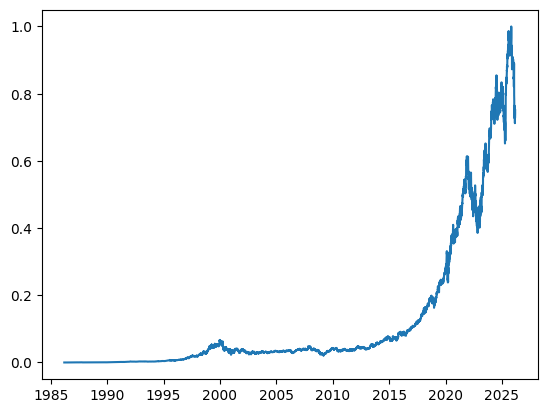

In [ ]:
df.index = df.pop("Date")

plt.plot(df)
plt.show()

## 3. Data Scaling

In [ ]:
print("price_scaler max:", price_scaler.data_max_)

price_scaler max: [539.82519531]


## 4. Creating Time Sequences

We use a **60-day sliding window** to capture short-term temporal dependencies in the stock price before predicting the next day's closing price. Each training sample consists of 60 consecutive days of scaled prices as input features, with the following day as the target.

In [ ]:
import pandas as pd
import numpy as np
import datetime

def str_to_datetime(s):
    return datetime.datetime.strptime(s, "%Y-%m-%d")


def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):

  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date

  dates = []
  X, Y = [], []

  last_time = False

  while True:

    df_subset = dataframe.loc[:target_date].tail(n+1)

    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()

    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]

    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])

    next_date_str = next_datetime_str.split('T')[0]

    year, month, day = next_date_str.split('-')

    next_date = datetime.datetime(year=int(year), month=int(month), day=int(day))

    if last_time:
      break

    target_date = next_date

    if target_date == last_date:
      last_time = True

  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

  X = np.array(X)

  for i in range(0, n):
    ret_df[f'Target-{n-i}'] = X[:, i]

  ret_df['Target'] = Y

  return ret_df


windowed_df = df_to_windowed_df(
    df,
    '1986-06-18',
    '2026-03-04',
    n=60
)

windowed_df

,Target Date,Target-60,Target-59,Target-58,Target-57,Target-56,Target-55,Target-54,Target-53,Target-52,...,Target-9,Target-8,Target-7,Target-6,Target-5,Target-4,Target-3,Target-2,Target-1,Target
0,1986-06-18,0.000000,0.000002,0.000005,0.000007,0.000006,0.000005,0.000006,0.000007,0.000007,...,0.000032,0.000032,0.000026,0.000026,0.000026,0.000022,0.000022,0.000021,0.000023,0.000022
1,1986-06-19,0.000002,0.000005,0.000007,0.000006,0.000005,0.000006,0.000007,0.000007,0.000005,...,0.000032,0.000026,0.000026,0.000026,0.000022,0.000022,0.000021,0.000023,0.000022,0.000021
2,1986-06-20,0.000005,0.000007,0.000006,0.000005,0.000006,0.000007,0.000007,0.000005,0.000006,...,0.000026,0.000026,0.000026,0.000022,0.000022,0.000021,0.000023,0.000022,0.000021,0.000021
3,1986-06-23,0.000007,0.000006,0.000005,0.000006,0.000007,0.000007,0.000005,0.000006,0.000008,...,0.000026,0.000026,0.000022,0.000022,0.000021,0.000023,0.000022,0.000021,0.000021,0.000023
4,1986-06-24,0.000006,0.000005,0.000006,0.000007,0.000007,0.000005,0.000006,0.000008,0.000009,...,0.000026,0.000022,0.000022,0.000021,0.000023,0.000022,0.000021,0.000021,0.000023,0.000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999,2026-02-26,0.909340,0.899599,0.905625,0.882944,0.888693,0.892981,0.907510,0.909358,0.884479,...,0.742668,0.741707,0.733463,0.738527,0.738101,0.735822,0.712183,0.720575,0.742066,0.744141
10000,2026-02-27,0.899599,0.905625,0.882944,0.888693,0.892981,0.907510,0.909358,0.884479,0.893554,...,0.741707,0.733463,0.738527,0.738101,0.735822,0.712183,0.720575,0.742066,0.744141,0.727504
10001,2026-03-02,0.905625,0.882944,0.888693,0.892981,0.907510,0.909358,0.884479,0.893554,0.884423,...,0.733463,0.738527,0.738101,0.735822,0.712183,0.720575,0.742066,0.744141,0.727504,0.738268
10002,2026-03-03,0.882944,0.888693,0.892981,0.907510,0.909358,0.884479,0.893554,0.884423,0.877566,...,0.738527,0.738101,0.735822,0.712183,0.720575,0.742066,0.744141,0.727504,0.738268,0.748235


## 5. Convert to Arrays

In [ ]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()


  dates=df_as_np[:,0]

  middle_matrix = df_as_np[:,1:-1]
  X=middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y=df_as_np[:,-1]

  return dates,X.astype(np.float32),Y.astype(np.float32)

dates,X,y=windowed_df_to_date_X_y(windowed_df)


dates.shape,X.shape,y.shape


((10004,), (10004, 60, 1), (10004,))

## 6. Train / Validation / Test Split

Train: 9626 samples | Val: 189 | Test: 189


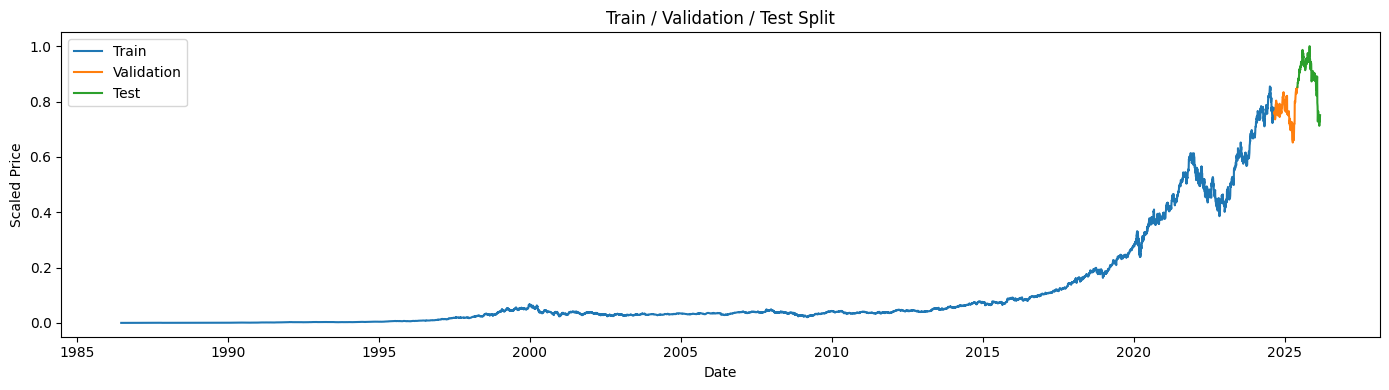

In [ ]:
# Use only last 5 years (~1260 trading days) — keeps model in the relevant
# modern price regime ($200–$540) rather than training on cheap historical data
recent_cutoff = len(dates) - 1260
q_80 = recent_cutoff + int(1260 * 0.7)
q_90 = recent_cutoff + int(1260 * 0.85)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val,   X_val,   y_val   = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test,  X_test,  y_test  = dates[q_90:], X[q_90:], y[q_90:]

print(f"Train: {len(dates_train)} samples | Val: {len(dates_val)} | Test: {len(dates_test)}")

plt.figure(figsize=(14,4))
plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val,   y_val,   label='Validation')
plt.plot(dates_test,  y_test,  label='Test')
plt.title('Train / Validation / Test Split')
plt.xlabel('Date')
plt.ylabel('Scaled Price')
plt.legend()
plt.tight_layout()
plt.show()


## 7. LSTM Model Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    layers.Input((60, 1)),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    loss="mse",
    optimizer=Adam(learning_rate=0.001),
    metrics=['mean_absolute_error']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                # stops if no improvement for 10 epochs
    restore_best_weights=True   # keeps best model automatically
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,497 (25.38 KB)

 Trainable params: 6,497 (25.38 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Model Training

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop]
)

model.summary()


Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0114 - mean_absolute_error: 0.0542 - val_loss: 7.1350e-04 - val_mean_absolute_error: 0.0205
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6896e-05 - mean_absolute_error: 0.0048 - val_loss: 5.5378e-04 - val_mean_absolute_error: 0.0190
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9243e-05 - mean_absolute_error: 0.0038 - val_loss: 5.8851e-04 - val_mean_absolute_error: 0.0189
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.2754e-05 - mean_absolute_error: 0.0030 - val_loss: 5.3706e-04 - val_mean_absolute_error: 0.0183
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1767e-05 - mean_absolute_error: 0.0028 - val_loss: 5.0705e-04 - val_mean_absolute_error: 0.0179
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8370e-05 - mean_absolute_error: 0.0026 - val_loss: 5.2888e-04 - val_mean_absolute_error: 0.0180
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1332e-0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,493 (76.15 KB)

 Trainable params: 6,497 (25.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,996 (50.77 KB)

## 9. Model Evaluation — Training Set

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


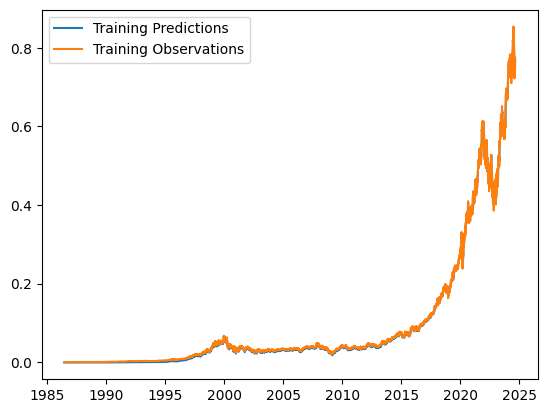

In [ ]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

## 10. Model Evaluation — Validation Set

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


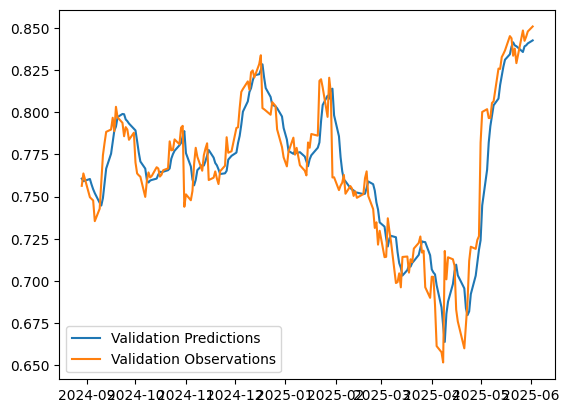

In [ ]:
val_predictions = model.predict(X_val).flatten()
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

## 11. Model Evaluation — Test Set

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


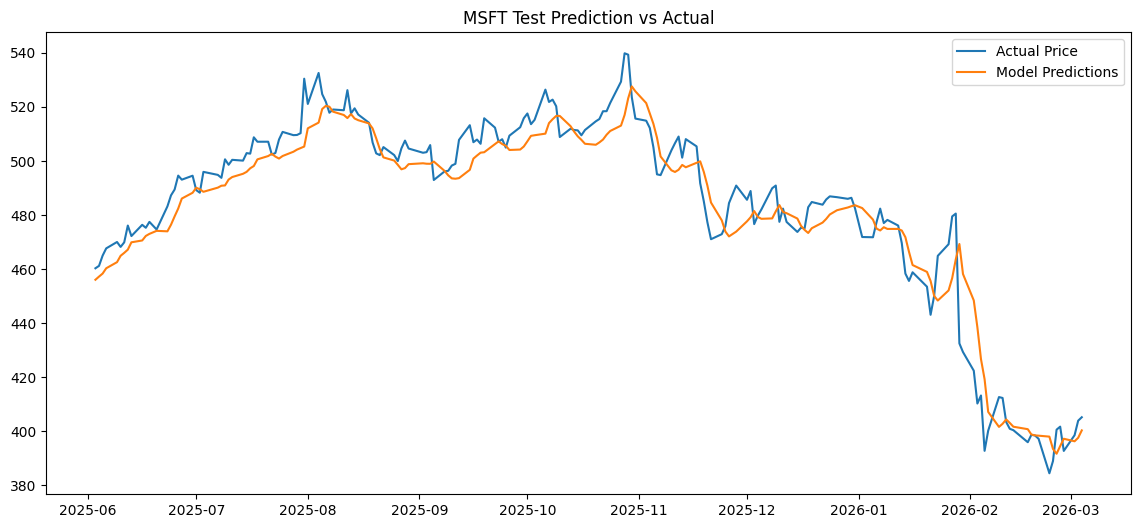

In [ ]:
train_predictions = model.predict(X_train).flatten()
val_predictions = model.predict(X_val).flatten()
test_predictions = model.predict(X_test).flatten()

train_predictions_real = price_scaler.inverse_transform(train_predictions.reshape(-1,1)).flatten()
y_train_real = price_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

val_predictions_real = price_scaler.inverse_transform(val_predictions.reshape(-1,1)).flatten()
y_val_real = price_scaler.inverse_transform(y_val.reshape(-1,1)).flatten()

test_predictions_real = price_scaler.inverse_transform(test_predictions.reshape(-1,1)).flatten()
y_test_real = price_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

plt.figure(figsize=(14,6))

plt.plot(dates_test, y_test_real, label="Actual Price")
plt.plot(dates_test, test_predictions_real, label="Model Predictions")

plt.title("MSFT Test Prediction vs Actual")
plt.legend()
plt.show()

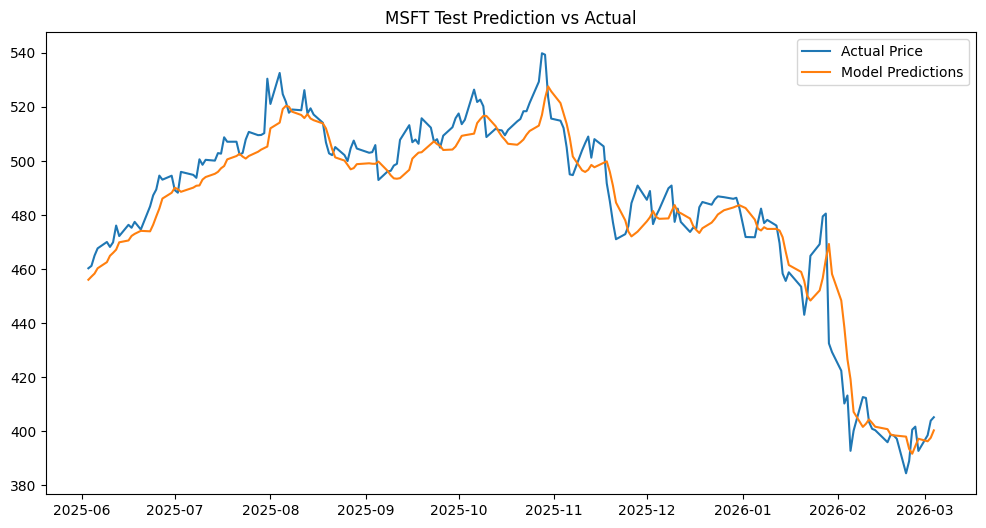

[0.8447938  0.8469722  0.84903044 0.8526721  0.85685617]
[456.0495  457.22537 458.33633 460.30197 462.56042]
[460.29605 461.1909  464.97888 467.66327 470.01962]


In [ ]:
plt.figure(figsize=(12,6))

plt.plot(dates_test, y_test_real, label="Actual Price")
plt.plot(dates_test, test_predictions_real, label="Model Predictions")

plt.legend()
plt.title("MSFT Test Prediction vs Actual")
plt.show()
print(test_predictions[:5])      # should be values around 0–1
print(test_predictions_real[:5]) # should be realistic prices
print(y_test_real[:5])

## 12. Error Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.013389105908572674
RMSE: 0.017396085271479064


## 13. MAPE

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, test_predictions)

print("MAPE:", mape)

MAPE: 0.015088395215570927


## 14. Baseline Comparison

In [ ]:
naive_predictions = y_test[:-1]

naive_mae = mean_absolute_error(y_test[1:], naive_predictions)

print("Naive MAE:", naive_mae)

Naive MAE: 0.008670738898217678


## 15. Training Loss Curve

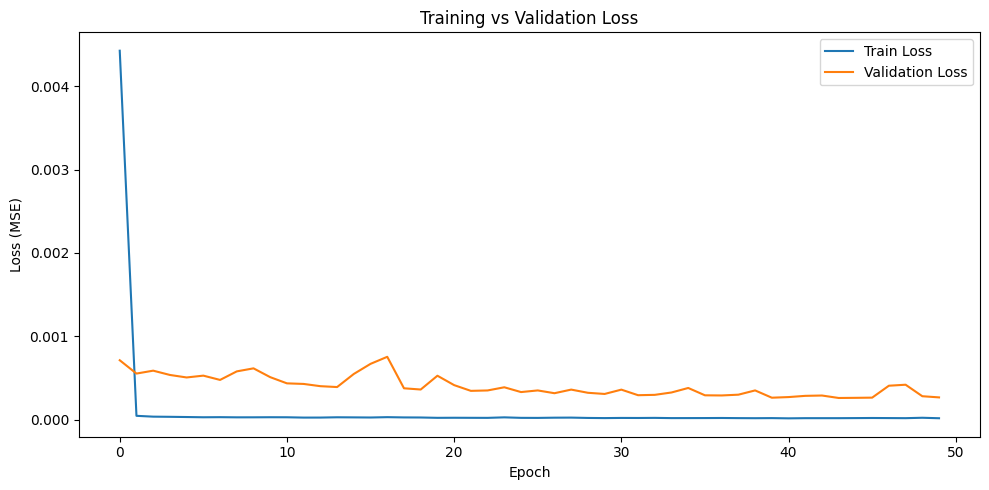

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()


## 16. Future Forecasting — Next 30 Trading Days

In [ ]:
import numpy as np

future_days = 30
future_predictions = []

current_window = X_test[-1]

for i in range(future_days):

    prediction = model.predict(current_window.reshape(1,60,1))[0][0]

    future_predictions.append(prediction)


    current_window = np.append(current_window[1:], [[prediction]], axis=0)

future_predictions = np.array(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

In [ ]:
# Generate future BUSINESS DAYS only — skips weekends like a real trading calendar
last_date = pd.Timestamp(dates[-1])
future_dates = pd.bdate_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_days
).tolist()
print("First 5 future dates:", [d.date() for d in future_dates[:5]])


First 5 future dates: [datetime.date(2026, 3, 5), datetime.date(2026, 3, 6), datetime.date(2026, 3, 9), datetime.date(2026, 3, 10), datetime.date(2026, 3, 11)]


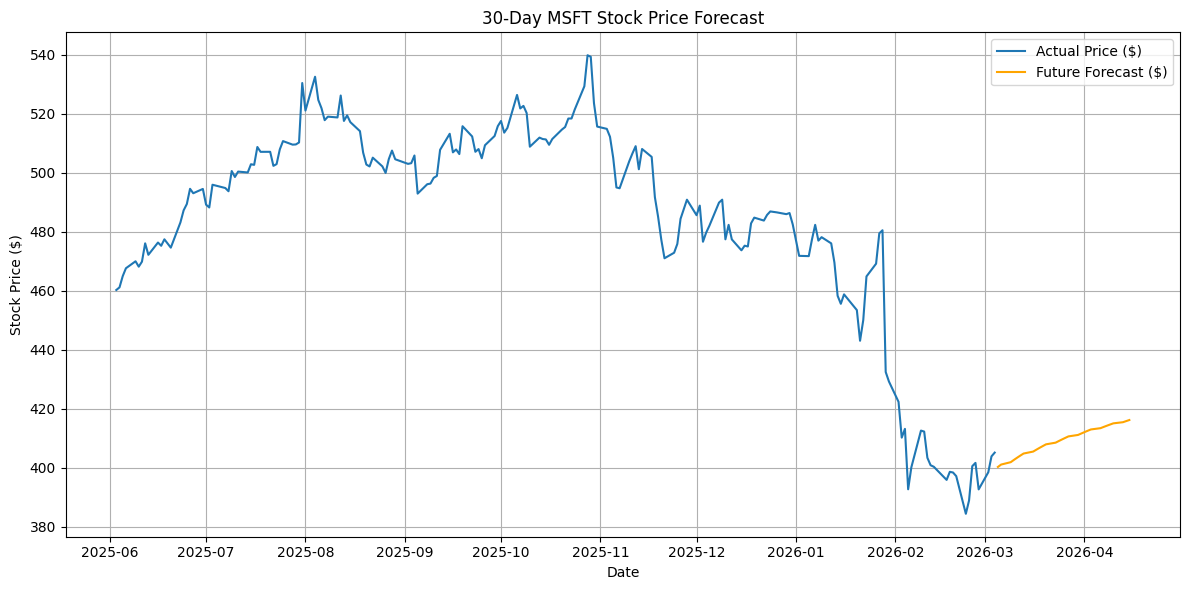

In [ ]:
import matplotlib.pyplot as plt

y_test_real_plot = price_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# Compute real USD prices for future forecast
future_predictions_real = price_scaler.inverse_transform(
    future_predictions.reshape(-1, 1)
).flatten()

plt.figure(figsize=(12,6))
plt.plot(dates_test, y_test_real_plot, label='Actual Price ($)')
plt.plot(future_dates, future_predictions_real, label='Future Forecast ($)', color='orange')
plt.title('30-Day MSFT Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 17. Final Visualization

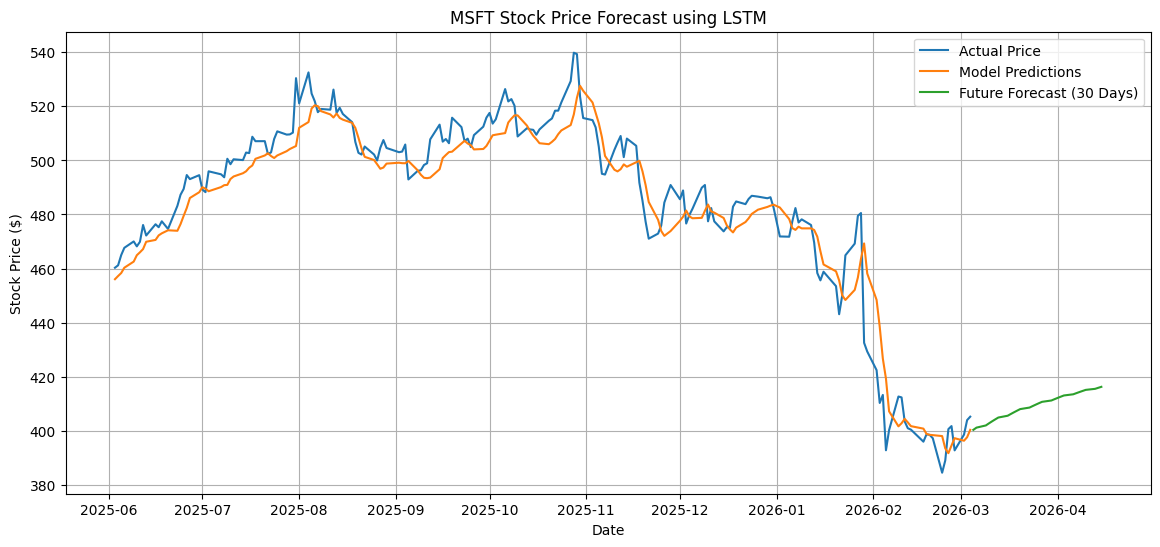

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(dates_test, y_test_real, label="Actual Price")
plt.plot(dates_test, test_predictions_real, label="Model Predictions")
plt.plot(future_dates, future_predictions_real, label="Future Forecast (30 Days)")

plt.title("MSFT Stock Price Forecast using LSTM")
plt.xlabel("Date")
plt.ylabel("Stock Price ($)")

plt.legend()
plt.grid(True)
plt.show()